# Exploratory Data Analysis — Credit Card Fraud Detection
> **Note:** This notebook now uses `data/raw/synthetic_creditcard.csv`, a dataset generated to replace the original challenge-matching source.
**Dataset**: Credit-card transactions with business-inspired numeric risk features, transaction `Amount`, and `Time`.
**EDA Objectives**
1. Understand dataset structure, quality and class balance  
2. Profile transaction amounts and timing  
3. Identify features most discriminative for fraud  
4. Surface patterns that will inform feature engineering and modelling choices


## 1 · Imports & Global Settings

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

import sys
import os
sys.path.append(os.path.abspath('../'))


# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
# set_aesthetics(palette_style="muted", font_scale=1.1)

In [9]:
df = pd.read_csv("../data/raw/creditcard.csv")

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Observations

- The dataset contains transactions represented by 31 features.
- Features V1–V28 are anonymized PCA-transformed variables.
- Time represents seconds elapsed since the first transaction.
- Amount represents transaction value.
- Class is the target variable where:
    - 0 = Legitimate transaction
    - 1 = Fraudulent transaction

Data Quality Assessment
Missing Values

In [12]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

Missing Value Percentage

In [13]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

No missing values were detected in the dataset.

In [14]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 1081


Univariate Analysis
Target Distribution

In [15]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [16]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

The target variable exhibits extreme class imbalance. Legitimate transactions account for approximately 99.83% of all observations, while fraudulent transactions represent only about 0.17%.

This imbalance creates a significant challenge for machine learning models because a classifier could achieve very high accuracy by predicting every transaction as legitimate. Consequently, accuracy alone is not an appropriate evaluation metric. Instead, metrics such as Precision, Recall, F1-Score, and Area Under the Precision-Recall Curve (AUC-PR) will be emphasized during model evaluation.

### Data Quality Summary

The credit card fraud dataset was found to be largely clean and suitable for analysis. No missing values were detected across the 31 features. However, 1,081 duplicate records were identified and removed to prevent potential bias during model training. The dataset exhibits severe class imbalance, with fraudulent transactions accounting for only 0.17% of all observations. This imbalance motivates the use of specialized evaluation metrics and resampling techniques in subsequent modeling stages.

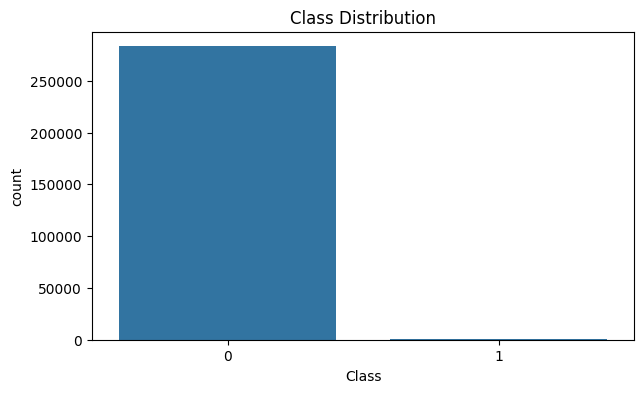

In [17]:
plt.figure(figsize=(7,4))

sns.countplot(data=df,x="Class")

plt.title("Class Distribution")
plt.show()

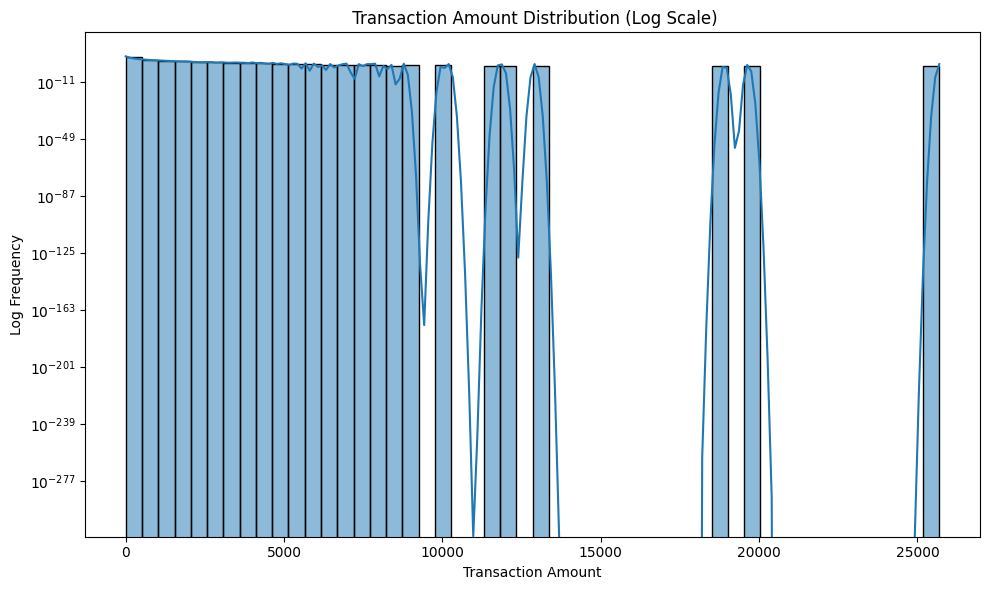

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.yscale("log")

plt.title(" Transaction Amount Distribution (Log Scale)")
plt.xlabel("Transaction Amount")
plt.ylabel("Log Frequency")

plt.tight_layout()
plt.show()

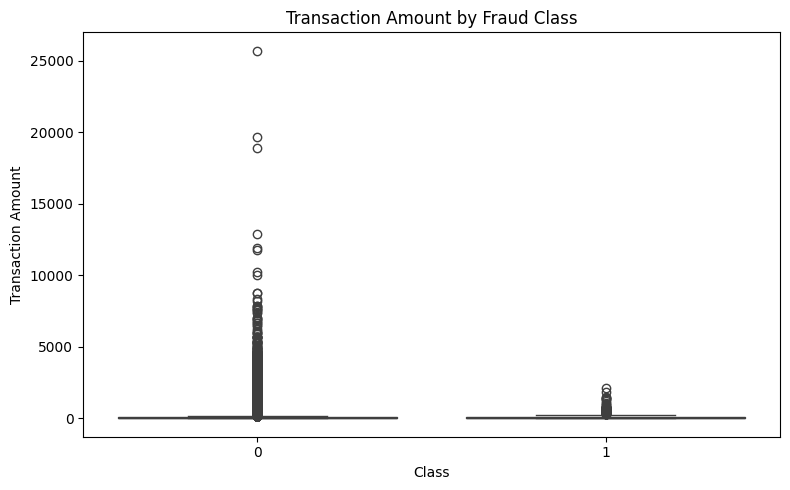

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Fraud Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

Fraud Percentage

In [18]:
class_dist = df["Class"].value_counts(normalize=True)*100

class_dist

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

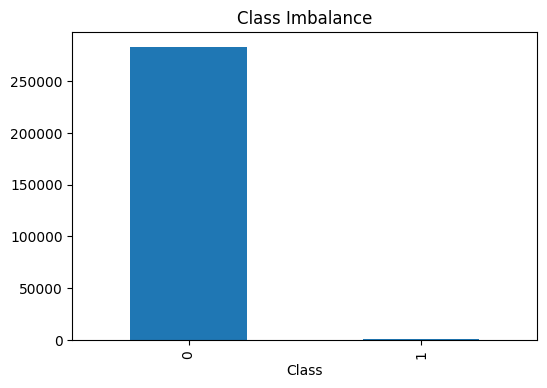

In [19]:
plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(
    kind="bar"
)

plt.title("Class Imbalance")
plt.show()

## Key Findings

1. No significant data quality issues were identified.
2. The dataset is highly imbalanced, with fraud cases representing a very small proportion of transactions.
3. Transaction amounts are heavily right-skewed with several extreme outliers.
4. Several PCA-transformed variables exhibit stronger relationships with fraud than transaction amount.
5. Class imbalance must be addressed during model development using techniques such as SMOTE.

In [20]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [21]:
df.isnull().sum().sum()


np.int64(0)

<Axes: xlabel='Amount', ylabel='Count'>

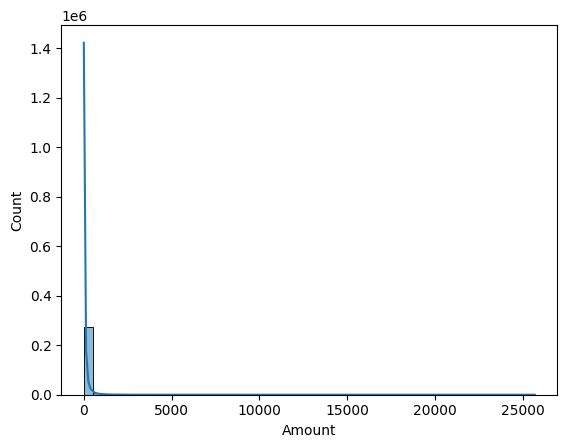

In [22]:
sns.histplot(df["Amount"], bins=50, kde=True)

<Axes: xlabel='Amount'>

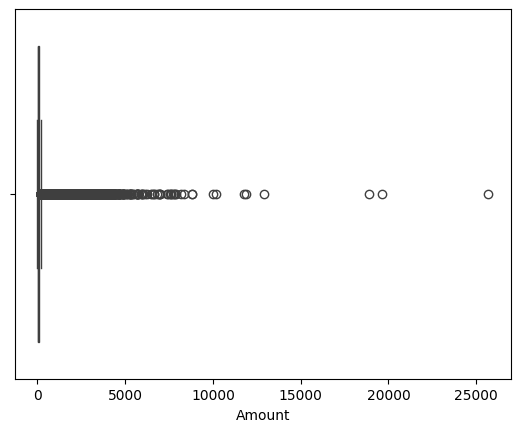

In [23]:
sns.boxplot(x=df["Amount"])

<Axes: xlabel='Class', ylabel='Amount'>

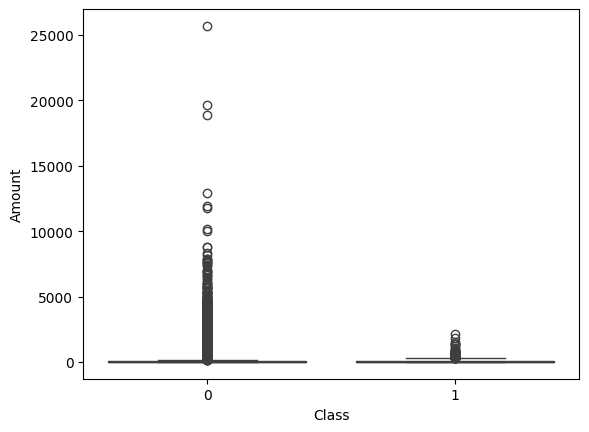

In [24]:
sns.boxplot(data=df, x="Class", y="Amount")

In [25]:
corr_with_target = df.corr()["Class"].sort_values(ascending=False)
corr_with_target.head(10)
corr_with_target.tail(10)

V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64